In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [4]:
img = cv2.cvtColor(cv2.imread("/mnt/d/Computer-Vision/Image-Processing/data/lowlightroom.jpg"),cv2.COLOR_BGR2RGB)
img_hsv = cv2.cvtColor(img, cv2.COLOR_RGB2HSV)

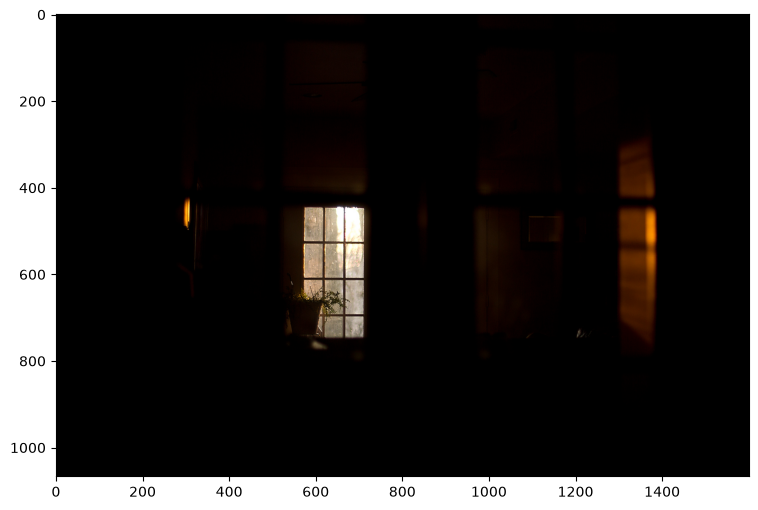

In [5]:
plt.figure(figsize=(12,6))
plt.imshow(img)
plt.show()

In [6]:
img_hsv.max()

np.uint8(255)

In [7]:
img_hsv.min()

np.uint8(0)

In [8]:
h,s,v = cv2.split(img_hsv)

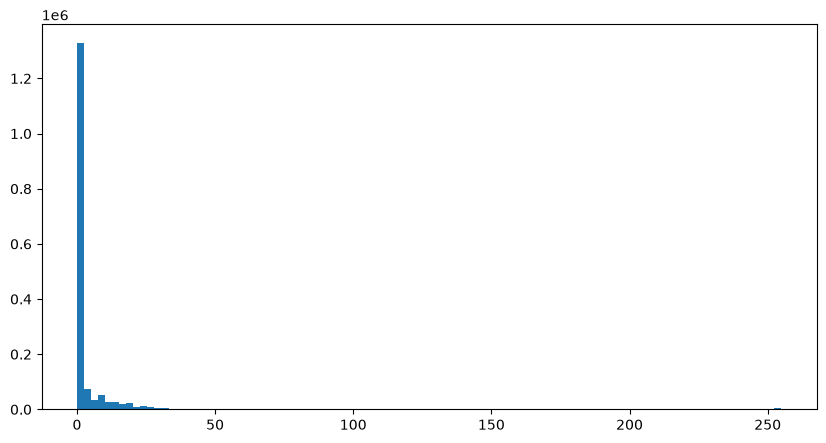

In [9]:
plt.figure(figsize=(10,5))
plt.hist(v.reshape(-1),bins=100)
plt.show()

In [10]:
def img_hsv_show(img_hsv):
    img_show = cv2.cvtColor(img_hsv,cv2.COLOR_HSV2RGB)
    plt.imshow(img_show)
    print(f'image shape: {img_show.shape}')
    plt.show()

In [11]:
# Stretching - HSV

In [12]:
i_min = v.min()
i_max = v.max()
v_stretched = ((v - i_min) / (i_max - i_min) * 255).astype('uint8')
img_stretched = cv2.merge([h,s,v_stretched])

image shape: (1067, 1600, 3)


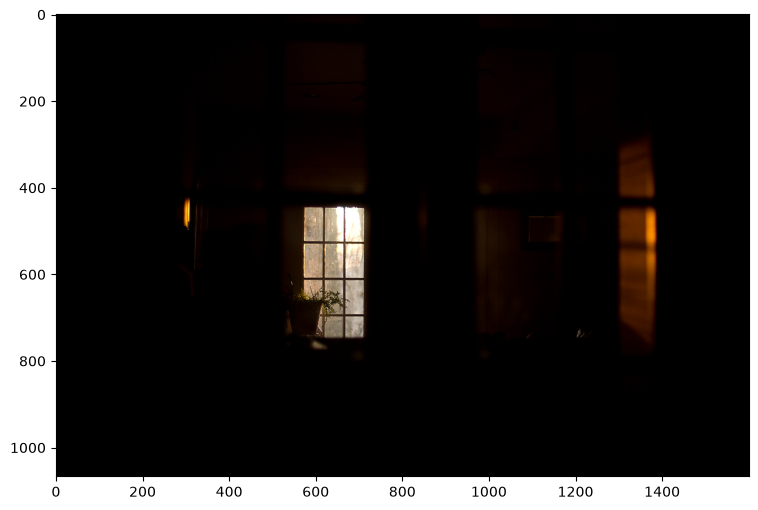

In [13]:
plt.figure(figsize=(12,6))
img_hsv_show(img_stretched)

In [14]:
# Stretching - RGB

In [15]:
# color image
streched_channels = []
img_channel = cv2.split(img)
for ch in img_channel:
    i_min = ch.min()
    i_max = ch.max()
    ch_stretched = ((ch - i_min) / (i_max - i_min) * 255).astype('uint8')
    streched_channels.append(ch_stretched)

img_rgb_stretched = cv2.merge(streched_channels)

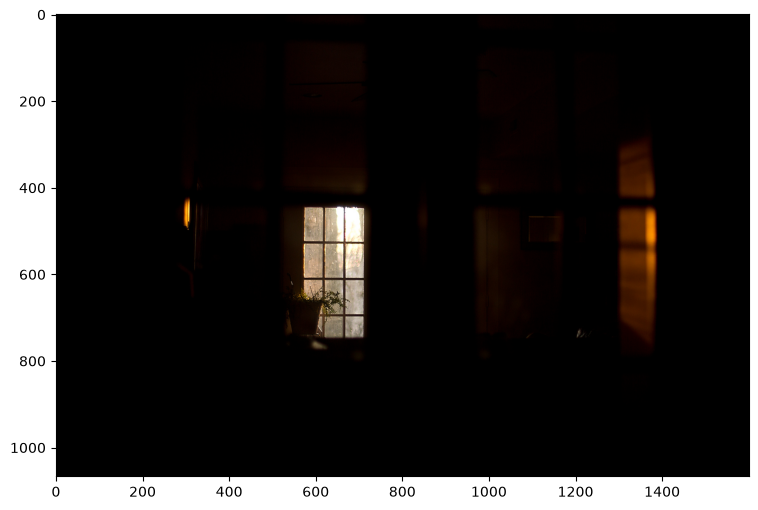

In [16]:
plt.figure(figsize=(12,6))
plt.imshow(img_rgb_stretched)
plt.show()

In [17]:
# Equalization - HSV

In [18]:
v_equ = cv2.equalizeHist(v)
img_hsv_equ = cv2.merge([h,s,v_equ])

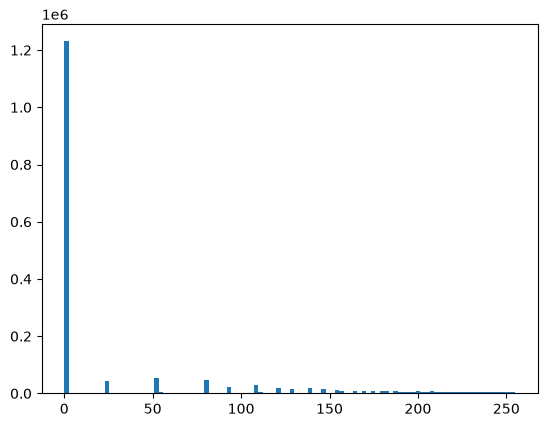

In [19]:
plt.hist(v_equ.reshape(-1),bins=100)
plt.show()

image shape: (1067, 1600, 3)


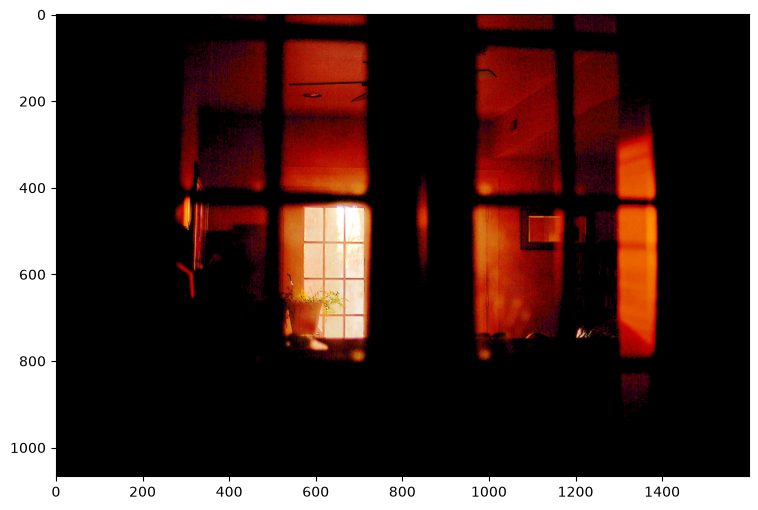

In [20]:
plt.figure(figsize=(12,6))
img_hsv_show(img_hsv_equ)

In [21]:
# CLAHE - RGB

In [22]:
chlahe_channels = []
img_channel = cv2.split(img)
for ch in img_channel:
    clahe = cv2.createCLAHE(clipLimit=3,tileGridSize=(8,8))
    clahe_ch = clahe.apply(ch)
    chlahe_channels.append(clahe_ch)

img_rgb_clahe = cv2.merge(chlahe_channels)

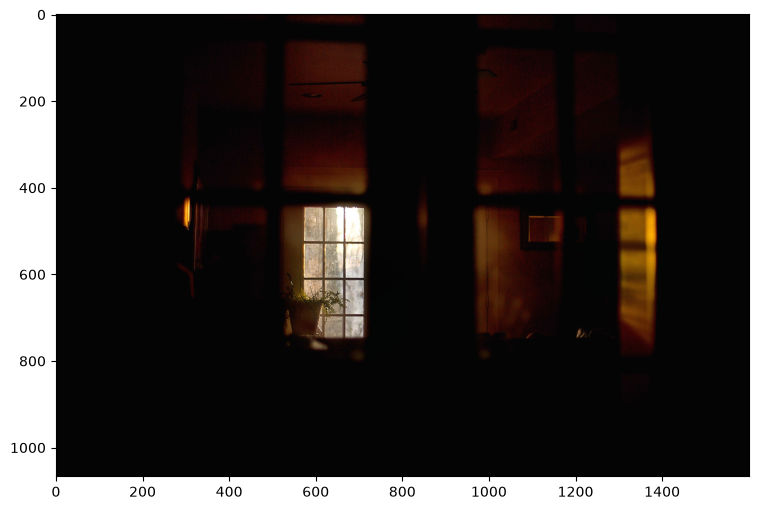

In [23]:
plt.figure(figsize=(12,6))
plt.imshow(img_rgb_clahe)
plt.show()

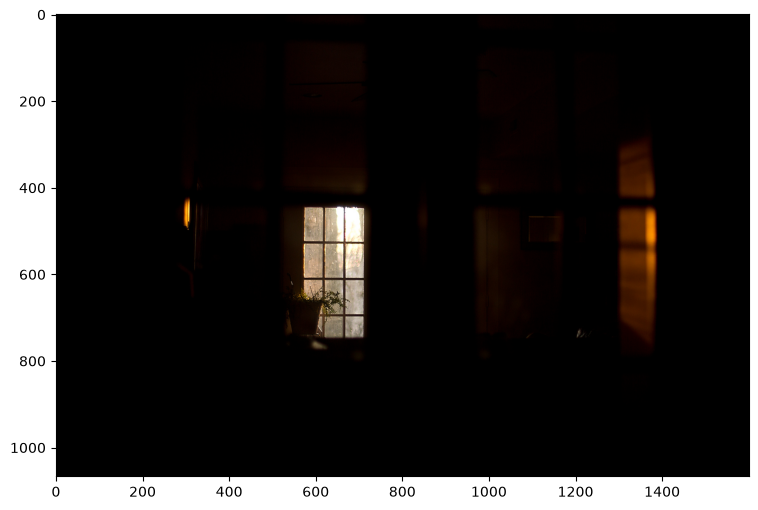

In [24]:
plt.figure(figsize=(12,6))
plt.imshow(img)
plt.show()